# RNN v1 — Piloto LSTM/GRU sobre `ACCEL_RMS` (Fase 10, experimental)

**Objetivo.** Evaluar si modelos secuenciales (LSTM y GRU, PyTorch CPU, entorno separado `tfm-rnn`)
mejoran al baseline tabular sobre el target `ACCEL_RMS` en condición `all`, respetando la partición
temporal por días del pipeline reproducible. Ventanas de 20 y 60 pasos sobre el orden de filas
existente; escaladores ajustados solo sobre entrenamiento; early stopping sobre la cola temporal
del train (15 %). Entrenamiento ejecutado por `src/experiments/train_rnn_v1_sequence.py`; este
notebook consume sus artefactos, construye el leaderboard global y emite el veredicto.

**Reglas de salida:** sin filas crudas del dataset — solo shapes, hiperparámetros, métricas,
tablas agregadas y figuras.

*Documento experimental de la rama `phase-10-rnn-sequence-models`. No forma parte del entregable.*

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
RES = REPO / "reports" / "results"

rnn = pd.read_csv(RES / "rnn_v1_results.csv")
print("Experimentos RNN:", len(rnn), "| target:", rnn["target"].unique(), "| condicion:", rnn["load_condition"].unique())
cols = ["experiment", "seq_len", "best_epoch", "epochs_run", "fit_s", "MAE", "MSE", "RMSE", "R2", "delta_r2_vs_lightgbm"]
display(rnn[cols].round(4))

Experimentos RNN: 4 | target: <StringArray>
['ACCEL_RMS']
Length: 1, dtype: str | condicion: <StringArray>
['all']
Length: 1, dtype: str


,experiment,seq_len,best_epoch,epochs_run,fit_s,MAE,MSE,RMSE,R2,delta_r2_vs_lightgbm
0,LSTM_seq20_h128x2,20,3,13,244.1285,52.5109,6533.2655,80.8286,0.6856,-0.1691
1,LSTM_seq60_h128x2,60,7,17,745.6371,60.4242,8957.8990,94.6462,0.5690,-0.2857
2,GRU_seq20_h128x2,20,6,16,479.8193,52.6131,6403.6640,80.0229,0.6919,-0.1628
3,GRU_seq60_h128x2,60,7,17,1063.0578,53.0849,6522.4094,80.7614,0.6862,-0.1685


## 1. Curvas de entrenamiento (val MSE escalado, cola temporal del train)

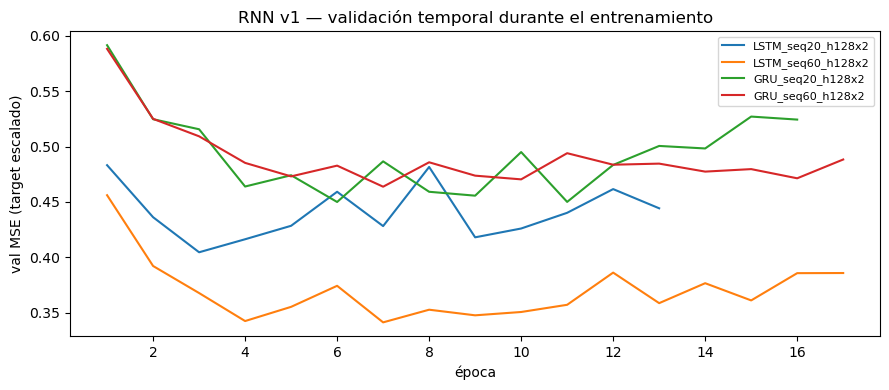

In [2]:
history = json.loads((RES / "rnn_v1_history.json").read_text(encoding="utf-8"))
fig, ax = plt.subplots(figsize=(9, 4))
for exp, curve in history.items():
    ax.plot([c["epoch"] for c in curve], [c["val_mse"] for c in curve], label=exp)
ax.set_xlabel("época")
ax.set_ylabel("val MSE (target escalado)")
ax.set_title("RNN v1 — validación temporal durante el entrenamiento")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Leaderboard global — `ACCEL_RMS`, condición `all`

Mejor resultado por familia: árboles y boosting del registro factorial (`01_models_v2_results.csv`,
mejor entre single/multi), la mejor red densa (MLP v5, notebook autocontenido de la Fase 9) y los
cuatro pilotos RNN de esta fase.

In [3]:
FAMILY = {
    "RandomForest": "arboles (bagging)",
    "XGBoost": "boosting de arboles",
    "LightGBM": "boosting de arboles",
    "CatBoost": "boosting de arboles",
    "MLPRegressor": "red densa (sklearn)",
    "LSTM": "RNN (PyTorch CPU)",
    "GRU": "RNN (PyTorch CPU)",
}
NOTE = "offline temporal split"

reg = pd.read_csv(RES / "01_models_v2_results.csv")
reg = reg[(reg["target"] == "ACCEL_RMS") & (reg["load"] == "all") & (reg["model"] != "MLPRegressor")]
best_reg = reg.loc[reg.groupby("model")["R2"].idxmax()]

rows = []
for _, r in best_reg.iterrows():
    rows.append({"model": r["model"], "family": FAMILY[r["model"]], "target": "ACCEL_RMS",
                 "load_condition": "all", "MAE": r["MAE"], "MSE": r["MSE"], "RMSE": r["RMSE"],
                 "R2": r["R2"], "fit_s": r["fit_s"], "note": NOTE})

mlp = pd.read_csv(RES / "neural_mlp_v5_results.csv")
m = mlp.loc[mlp["r2"].idxmax()]
rows.append({"model": f"MLP v5 {m['hidden_layer_sizes']}", "family": FAMILY["MLPRegressor"],
             "target": "ACCEL_RMS", "load_condition": "all", "MAE": m["mae"], "MSE": m["mse"],
             "RMSE": m["rmse"], "R2": m["r2"], "fit_s": m["fit_s"], "note": NOTE})

for _, r in pd.read_csv(RES / "rnn_v1_results.csv").iterrows():
    rows.append({"model": r["experiment"], "family": FAMILY[r["model"]], "target": "ACCEL_RMS",
                 "load_condition": "all", "MAE": r["MAE"], "MSE": r["MSE"], "RMSE": r["RMSE"],
                 "R2": r["R2"], "fit_s": r["fit_s"], "note": NOTE})

board = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
board.to_csv(RES / "model_leaderboard_all.csv", index=False)
print("Guardado:", RES / "model_leaderboard_all.csv", "|", board.shape)
display(board.round(4))

Guardado: reports/results/model_leaderboard_all.csv | (9, 10)


,model,family,target,load_condition,MAE,MSE,RMSE,R2,fit_s,note
0,LightGBM,boosting de arboles,ACCEL_RMS,all,26.5000,3020.7390,54.9610,0.8547,2.8700,offline temporal split
1,XGBoost,boosting de arboles,ACCEL_RMS,all,26.7630,3032.8490,55.0710,0.8541,0.8400,offline temporal split
2,RandomForest,arboles (bagging),ACCEL_RMS,all,27.7330,3090.1550,55.5890,0.8513,9.9700,offline temporal split
3,CatBoost,boosting de arboles,ACCEL_RMS,all,29.8450,3350.8130,57.8860,0.8388,1.5100,offline temporal split
4,"MLP v5 (2048, 1024, 512)",red densa (sklearn),ACCEL_RMS,all,32.5815,4152.1592,64.4372,0.8002,985.3929,offline temporal split
5,GRU_seq20_h128x2,RNN (PyTorch CPU),ACCEL_RMS,all,52.6131,6403.6640,80.0229,0.6919,479.8193,offline temporal split
6,GRU_seq60_h128x2,RNN (PyTorch CPU),ACCEL_RMS,all,53.0849,6522.4094,80.7614,0.6862,1063.0578,offline temporal split
7,LSTM_seq20_h128x2,RNN (PyTorch CPU),ACCEL_RMS,all,52.5109,6533.2655,80.8286,0.6856,244.1285,offline temporal split
8,LSTM_seq60_h128x2,RNN (PyTorch CPU),ACCEL_RMS,all,60.4242,8957.8990,94.6462,0.5690,745.6371,offline temporal split


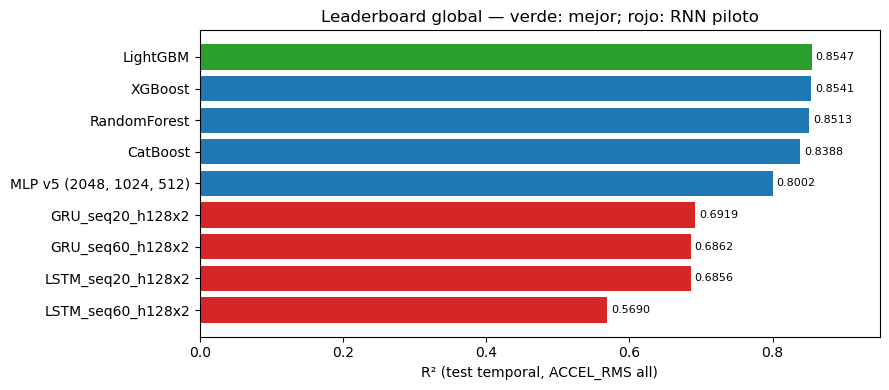

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:green" if i == 0 else "tab:blue" for i in range(len(board))]
ax.barh(board["model"][::-1], board["R2"][::-1],
        color=[("tab:green" if m == board.iloc[0]["model"] else
                ("tab:red" if f == "RNN (PyTorch CPU)" else "tab:blue"))
               for m, f in zip(board["model"][::-1], board["family"][::-1])])
ax.set_xlabel("R² (test temporal, ACCEL_RMS all)")
ax.set_xlim(0, 0.95)
ax.set_title("Leaderboard global — verde: mejor; rojo: RNN piloto")
for y, v in enumerate(board["R2"][::-1]):
    ax.text(v + 0.005, y, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Veredicto

In [5]:
best_global = board.iloc[0]
best_rnn = board[board["family"] == "RNN (PyTorch CPU)"].iloc[0]
lgbm_r2 = float(board.loc[board["model"] == "LightGBM", "R2"].iloc[0])
print(f"Mejor modelo global : {best_global['model']} (R2={best_global['R2']:.4f})")
print(f"Mejor RNN           : {best_rnn['model']} (R2={best_rnn['R2']:.4f})")
if best_rnn["R2"] > lgbm_r2:
    print("VEREDICTO: la RNN SUPERA a LightGBM en este test temporal.")
else:
    print(f"VEREDICTO: la RNN NO supera a LightGBM (deficit = {lgbm_r2 - best_rnn['R2']:.4f} puntos de R2).")
    print("El boosting de arboles sigue siendo el enfoque mas solido para este problema con las variables disponibles.")

Mejor modelo global : LightGBM (R2=0.8547)
Mejor RNN           : GRU_seq20_h128x2 (R2=0.6919)
VEREDICTO: la RNN NO supera a LightGBM (deficit = 0.1628 puntos de R2).
El boosting de arboles sigue siendo el enfoque mas solido para este problema con las variables disponibles.


## 4. Conclusión

El veredicto de la celda anterior se calcula de las métricas de esta ejecución. Este piloto responde
a la hipótesis del Capítulo 11 de la memoria (formulación secuencial del problema): con las variables
tabulares del PLC a 5 Hz, ventanas de 20–60 pasos y arquitecturas recurrentes estándar (LSTM/GRU,
128×2), el modelado secuencial no cambia —con esta evidencia— la conclusión del registro principal.

**Sobre la integración en la memoria entregable:** este experimento usa PyTorch en un entorno
separado y rompe deliberadamente la paridad bit-a-bit del baseline (coste ya previsto en §11.7).
Se recomienda mantenerlo como evidencia experimental de la rama `phase-10-rnn-sequence-models`
—citable en la defensa como exploración adicional— y no modificar la memoria final.